# Audio_Moth Modeling (acoustics) Analysis

## Import Packages and Load Data


In [2]:
import sys; print(sys.executable)

/Volumes/MacData/KWF/ML Analysis/venv_arm_fixed/bin/python


In [5]:
%pip install -q hdbscan

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import chi2_contingency
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, precision_score,
                             recall_score, f1_score, classification_report, 
                             roc_auc_score, RocCurveDisplay, auc,silhouette_score,
                             adjusted_rand_score,precision_recall_curve,
                             average_precision_score,roc_curve)
import hdbscan
import lightgbm as lgb



import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import xgboost as xgb
from xgboost import XGBClassifier



plt.style.use('default')
sns.set_palette("husl")

In [ ]:
file_path = 'combined.csv'
file_path_feature1_17 = 'new_sound_features_1_17.csv'
file_path_feature1_18 = 'new_sound_features_1_18.csv'
file_path_feature3 = 'new_sound_features_3.csv'
file_path_feature_other = 'new_sound_features_other.csv'

df = pd.read_csv(file_path)
df_feature1_17 = pd.read_csv(file_path_feature1_17)
df_feature1_18 = pd.read_csv(file_path_feature1_18)
df_feature3 = pd.read_csv(file_path_feature3)
df_feature_other = pd.read_csv(file_path_feature_other)


In [ ]:
df_feature1_17['Tempo (BPM)'] = df_feature1_17['Tempo (BPM)'].str.strip('[]').astype(float)
df_feature1_18['Tempo (BPM)'] = df_feature1_18['Tempo (BPM)'].str.strip('[]').astype(float)
df_feature3['Tempo (BPM)'] = df_feature3['Tempo (BPM)'].str.strip('[]').astype(float)
df_feature_other['Tempo (BPM)'] = df_feature_other['Tempo (BPM)'].str.strip('[]').astype(float)


In [ ]:
def load_csv(df):
    cols = ['species', 'confidence', 'Sim Type', 'Sim Relative Time']
    for col in cols:
        df[col] = df[col].apply(ast.literal_eval)
    return df

df = load_csv(df)

df_expl = df.copy()
df_expl['clip_dt'] = pd.to_datetime(df['Timestamp'], format='%Y%m%d_%H%M%S')

df_expl = (
    df_expl.explode(['Sim Type','Sim Relative Time'])
      .rename(columns={'Sim Type':'sim_name',
                       'Sim Relative Time':'sim_rel_time'})
      .reset_index(drop=True)
)

df_expl = df_expl.explode('species', ignore_index=True)
df_expl['is_start'] = (df_expl['sim_rel_time'] == 0) & (df_expl['sim_name'].notna())


In [ ]:
def add_prefix(df, prefix):
    return df.rename(
        columns={c: f"{prefix}_{c}" for c in df.columns if c != "clip_name"}
    )

df17   = add_prefix(df_feature1_17, "f17")
df18   = add_prefix(df_feature1_18, "f18")
df3    = add_prefix(df_feature3,    "f3")
df_other = add_prefix(df_feature_other, "other")

df_all_feat = pd.concat([df17, df18, df3, df_other], axis=0, ignore_index=True)
df_comb = df_expl.merge(df_all_feat, on="clip_name", how="left")

feature_cols = [
    'RMS Energy', 'Spectral Bandwidth', 'Spectral Rolloff (85%)',
    'Spectral Flatness', 'Spectral Contrast', 'Tempo (BPM)', 'Onset Strength'
]

for col in feature_cols:
    df_comb[col] = (
        df_comb[f"f17_{col}"]
              .combine_first(df_comb[f"f18_{col}"])
              .combine_first(df_comb[f"f3_{col}"])
              .combine_first(df_comb[f"other_{col}"])
    )

prefixed = df_comb.filter(regex=r"^(f17_|f18_|f3_|other_)").columns
df_comb = df_comb.drop(columns=prefixed).copy()

print("Combined dataset shape:", df_comb.shape)


Combined dataset shape: (660722, 40)


In [11]:
df_comb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 660722 entries, 0 to 660721
Data columns (total 40 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   clip_name               660722 non-null  object        
 1   Recorder                660722 non-null  object        
 2   Timestamp               660722 non-null  object        
 3   Duration (sec)          660722 non-null  float64       
 4   Sample Rate (Hz)        660722 non-null  int64         
 5   Channels                660722 non-null  int64         
 6   Bit Depth               660722 non-null  int64         
 7   File Size (KB)          660722 non-null  float64       
 8   Battery Voltage         660722 non-null  object        
 9   Gain                    660722 non-null  object        
 10  Spectral Centroid       660722 non-null  float64       
 11  Zero Crossing Rate      660722 non-null  float64       
 12  Human Activity          660722

In [ ]:
all_feature_cols = [
    'Spectral Centroid',
    'Zero Crossing Rate', 
    'RMS Energy',
    'Spectral Bandwidth', 
    'Spectral Rolloff (85%)',
    'Spectral Flatness', 
    'Spectral Contrast', 
    'Tempo (BPM)', 
    'Onset Strength'
]

df_comb["sim_flag"] = df_comb["sim_name"].notna().astype(int)
df_comb["human_presence"] = (df_comb["Human Activity"] != "no").astype(int)

#Dataset A: Audio_Moth_1 only (open area)
df_moth1 = df_comb[df_comb['Recorder'] == 'Audio_Moth_1'].copy()
print(f"Dataset A (Audio_Moth_1 - open area): {df_moth1.shape[0]} samples")

#Dataset B: All Audio_Moth recorders (including moth1)
df_all_moths = df_comb[df_comb['Recorder'].str.contains('Audio_Moth', na=False)].copy()
print(f"Dataset B (All Audio_Moth recorders): {df_all_moths.shape[0]} samples")

print(f"\nTotal samples: {len(df_comb)}")
print(f"Unique recorders: {df_comb['Recorder'].unique()}")
print(f"Audio_Moth recorders: {df_all_moths['Recorder'].unique()}")

def prepare_features(df, dataset_name):
    print(f"\n=== {dataset_name} ===")
    
    df_clean = df[all_feature_cols].replace([np.inf, -np.inf], np.nan).dropna()
    keep_idx = df_clean.index
    df_subset = df.loc[keep_idx].copy()
    
    print(f"Shape after cleaning: {df_subset.shape}")
    print(f"Simulation samples: {df_subset['sim_flag'].sum()} ({df_subset['sim_flag'].mean():.2%})")
    print(f"Human presence samples: {df_subset['human_presence'].sum()} ({df_subset['human_presence'].mean():.2%})")
    
    return df_subset, df_clean.values

df_A, X_A = prepare_features(df_moth1, "Audio_Moth_1 (open area)")
df_B, X_B = prepare_features(df_all_moths, "All Audio_Moth recorders")

Dataset A (Audio_Moth_1 - open area): 129727 samples
Dataset B (All Audio_Moth recorders): 660722 samples

Total samples: 660722
Unique recorders: ['Audio_Moth_1' 'Audio_Moth_2' 'Audio_Moth_3' 'Audio_Moth_4'
 'Audio_Moth_5' 'Audio_Moth_6']
Audio_Moth recorders: ['Audio_Moth_1' 'Audio_Moth_2' 'Audio_Moth_3' 'Audio_Moth_4'
 'Audio_Moth_5' 'Audio_Moth_6']

=== Audio_Moth_1 (open area) ===
Shape after cleaning: (129727, 42)
Simulation samples: 1774 (1.37%)
Human presence samples: 252 (0.19%)

=== All Audio_Moth recorders ===
Shape after cleaning: (660722, 42)
Simulation samples: 18423 (2.79%)
Human presence samples: 759 (0.11%)


Feature Analysis and Standardization

In [ ]:
from sklearn.cluster import DBSCAN

def perform_pca_analysis(X, df_subset, dataset_name):
    """Perform PCA analysis and return transformed data"""
    print(f"\n=== PCA Analysis for {dataset_name} ===")
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca_full = PCA(random_state=42)
    pca_full.fit(X_scaled)
    
    print("Explained variance ratio by component:")
    for i, ratio in enumerate(pca_full.explained_variance_ratio_):
        print(f"Component {i+1}: {ratio:.2%} ({np.sum(pca_full.explained_variance_ratio_[:i+1]):.2%} cumulative)")
    
    n_components_90 = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.90) + 1
    print(f"Components needed for 90% variance: {n_components_90}")
    
    pca_cluster = PCA(n_components=min(5, len(all_feature_cols)), random_state=42)
    pca_viz = PCA(n_components=2, random_state=42)
    
    X_pca_cluster = pca_cluster.fit_transform(X_scaled)
    X_pca_viz = pca_viz.fit_transform(X_scaled)
    
    df_subset_copy = df_subset.copy()
    df_subset_copy['pca1'] = X_pca_viz[:, 0]
    df_subset_copy['pca2'] = X_pca_viz[:, 1]
    
    print(f"PCA clustering components explained variance: {pca_cluster.explained_variance_ratio_.sum():.2%}")
    print(f"PCA visualization components explained variance: {pca_viz.explained_variance_ratio_.sum():.2%}")
    
    return X_scaled, X_pca_cluster, X_pca_viz, df_subset_copy, scaler, pca_cluster, pca_viz

results_A = perform_pca_analysis(X_A, df_A, "Audio_Moth_1 (open area)")
X_A_scaled, X_A_pca_cluster, X_A_pca_viz, df_A_pca, scaler_A, pca_cluster_A, pca_viz_A = results_A

results_B = perform_pca_analysis(X_B, df_B, "All Audio_Moth recorders")
X_B_scaled, X_B_pca_cluster, X_B_pca_viz, df_B_pca, scaler_B, pca_cluster_B, pca_viz_B = results_B


=== PCA Analysis for Audio_Moth_1 (open area) ===
Explained variance ratio by component:
Component 1: 39.88% (39.88% cumulative)
Component 2: 25.71% (65.58% cumulative)
Component 3: 11.26% (76.84% cumulative)
Component 4: 10.93% (87.77% cumulative)
Component 5: 5.99% (93.76% cumulative)
Component 6: 3.56% (97.32% cumulative)
Component 7: 2.04% (99.36% cumulative)
Component 8: 0.55% (99.91% cumulative)
Component 9: 0.09% (100.00% cumulative)
Components needed for 90% variance: 5
PCA clustering components explained variance: 93.76%
PCA visualization components explained variance: 65.58%

=== PCA Analysis for All Audio_Moth recorders ===
Explained variance ratio by component:
Component 1: 50.01% (50.01% cumulative)
Component 2: 16.64% (66.65% cumulative)
Component 3: 12.69% (79.34% cumulative)
Component 4: 11.06% (90.39% cumulative)
Component 5: 4.20% (94.60% cumulative)
Component 6: 3.48% (98.08% cumulative)
Component 7: 1.41% (99.48% cumulative)
Component 8: 0.39% (99.87% cumulative)
C

Three similarly sized clusters (silhouette ≈ 0.32) emerge; simulation and human-presence clips are rare and across clusters, so clustering reflects natural acoustic variation.

## Clustering Analysis


In [14]:
def analyze_cluster_composition(df, cluster_col, target_col, target_name):
    """Analyze cluster composition for a target variable"""
    crosstab = pd.crosstab(df[cluster_col], df[target_col], normalize='index')
    print(f"\n{target_name} distribution by cluster (row percentages):")
    print(crosstab.round(3))
    
    chi2, p_value, _, _ = chi2_contingency(pd.crosstab(df[cluster_col], df[target_col]))
    print(f"Chi-square test: χ² = {chi2:.3f}, p-value = {p_value:.6f}")
    
    return crosstab

In [15]:
print("=" * 60)
print("K-MEANS CLUSTERING - DATASET A (Audio_Moth_1)")
print("=" * 60)

scaler_A = StandardScaler()
X_A_scaled = scaler_A.fit_transform(X_A)

pca_A = PCA(n_components=5)
X_A_pca = pca_A.fit_transform(X_A_scaled)

kmeans_A = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_A = kmeans_A.fit_predict(X_A_pca)

df_A_clustered = df_A.copy()
df_A_clustered['cluster'] = clusters_A

print(f"Dataset A - K-Means with 3 clusters:")
print(f"Silhouette Score: {silhouette_score(X_A_pca, clusters_A):.3f}")
print(f"Cluster sizes: {np.bincount(clusters_A)}")

sim_crosstab_A = analyze_cluster_composition(df_A_clustered, 'cluster', 'sim_flag', 'Simulation')
human_crosstab_A = analyze_cluster_composition(df_A_clustered, 'cluster', 'human_presence', 'Human Presence')

K-MEANS CLUSTERING - DATASET A (Audio_Moth_1)
Dataset A - K-Means with 3 clusters:
Silhouette Score: 0.316
Cluster sizes: [36260 57696 35771]

Simulation distribution by cluster (row percentages):
sim_flag      0      1
cluster               
0         0.995  0.005
1         0.982  0.018
2         0.984  0.016
Chi-square test: χ² = 305.410, p-value = 0.000000

Human Presence distribution by cluster (row percentages):
human_presence      0      1
cluster                     
0               0.999  0.001
1               1.000  0.000
2               0.994  0.006
Chi-square test: χ² = 336.806, p-value = 0.000000


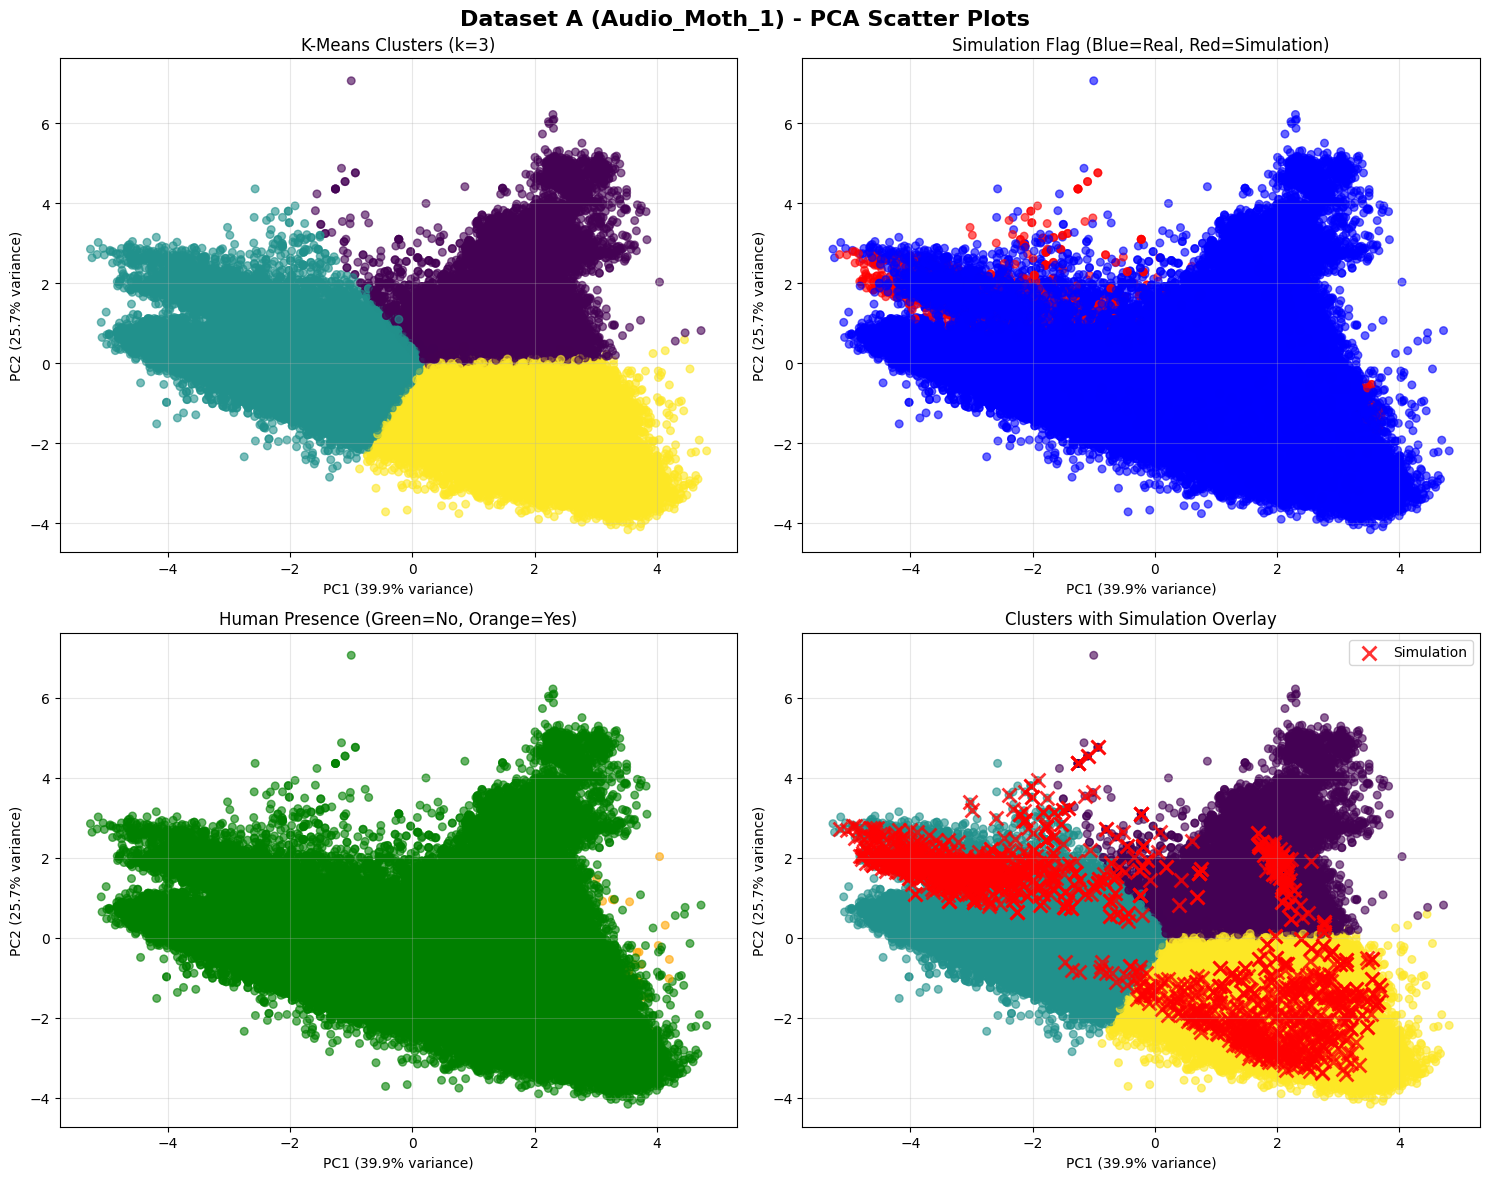

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Dataset A (Audio_Moth_1) - PCA Scatter Plots', fontsize=16, fontweight='bold')

pca_viz_A = PCA(n_components=2)
X_A_pca_viz = pca_viz_A.fit_transform(X_A_scaled)

# Plot 1: Clusters
axes[0,0].scatter(X_A_pca_viz[:, 0], X_A_pca_viz[:, 1], c=clusters_A, alpha=0.6, s=30)
axes[0,0].set_title('K-Means Clusters (k=3)')
axes[0,0].set_xlabel(f'PC1 ({pca_viz_A.explained_variance_ratio_[0]:.1%} variance)')
axes[0,0].set_ylabel(f'PC2 ({pca_viz_A.explained_variance_ratio_[1]:.1%} variance)')
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Simulation flag
sim_colors = ['blue' if x == 0 else 'red' for x in df_A_clustered['sim_flag']]
axes[0,1].scatter(X_A_pca_viz[:, 0], X_A_pca_viz[:, 1], c=sim_colors, alpha=0.6, s=30)
axes[0,1].set_title('Simulation Flag (Blue=Real, Red=Simulation)')
axes[0,1].set_xlabel(f'PC1 ({pca_viz_A.explained_variance_ratio_[0]:.1%} variance)')
axes[0,1].set_ylabel(f'PC2 ({pca_viz_A.explained_variance_ratio_[1]:.1%} variance)')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Human presence
human_colors = ['green' if x == 0 else 'orange' for x in df_A_clustered['human_presence']]
axes[1,0].scatter(X_A_pca_viz[:, 0], X_A_pca_viz[:, 1], c=human_colors, alpha=0.6, s=30)
axes[1,0].set_title('Human Presence (Green=No, Orange=Yes)')
axes[1,0].set_xlabel(f'PC1 ({pca_viz_A.explained_variance_ratio_[0]:.1%} variance)')
axes[1,0].set_ylabel(f'PC2 ({pca_viz_A.explained_variance_ratio_[1]:.1%} variance)')
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Combined view (clusters with simulation overlay)
scatter = axes[1,1].scatter(X_A_pca_viz[:, 0], X_A_pca_viz[:, 1], 
                           c=clusters_A, alpha=0.6, s=30)
sim_mask = df_A_clustered['sim_flag'] == 1
axes[1,1].scatter(X_A_pca_viz[sim_mask, 0], X_A_pca_viz[sim_mask, 1], 
                 marker='x', s=100, c='red', alpha=0.8, linewidth=2, label='Simulation')
axes[1,1].set_title('Clusters with Simulation Overlay')
axes[1,1].set_xlabel(f'PC1 ({pca_viz_A.explained_variance_ratio_[0]:.1%} variance)')
axes[1,1].set_ylabel(f'PC2 ({pca_viz_A.explained_variance_ratio_[1]:.1%} variance)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The K-means clustering on Audio_Moth_1 data reveals limited discriminative power of acoustic features for distinguishing simulations and human presence. 

While the clustering achieves reasonable quality (silhouette score = 0.316) with three balanced clusters, the simulation detection is weak - all clusters show very low simulation rates (0.5-1.8%), despite statistical significance. Human presence detection is even weaker, with rates near 0% across all clusters.

Simulation clips (red ×) cluster mainly in the upper-middle region but overlap all three clusters, while human-presence points are extremely sparse and non-separating.



In [ ]:
print("=" * 60)
print("K-MEANS CLUSTERING - DATASET B (All Audio_Moth)")
print("=" * 60)

scaler_B = StandardScaler()
X_B_scaled = scaler_B.fit_transform(X_B)

pca_B = PCA(n_components=4)
X_B_pca = pca_B.fit_transform(X_B_scaled)

kmeans_B = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_B = kmeans_B.fit_predict(X_B_pca)

df_B_clustered = df_B.copy()
df_B_clustered['cluster'] = clusters_B

print(f"Dataset B - K-Means with 4 clusters:")
print(f"Silhouette Score: {silhouette_score(X_B_pca, clusters_B):.3f}")
print(f"Cluster sizes: {np.bincount(clusters_B)}")

sim_crosstab_B = analyze_cluster_composition(df_B_clustered, 'cluster', 'sim_flag', 'Simulation')
human_crosstab_B = analyze_cluster_composition(df_B_clustered, 'cluster', 'human_presence', 'Human Presence')

print("\nRecorder distribution by cluster:")
recorder_crosstab = pd.crosstab(df_B_clustered['cluster'], df_B_clustered['Recorder'], normalize='index')
print(recorder_crosstab.round(3))

K-MEANS CLUSTERING - DATASET B (All Audio_Moth)
Dataset B - K-Means with 4 clusters:
Silhouette Score: 0.330
Cluster sizes: [ 69141 277434 198027 116120]

Simulation distribution by cluster (row percentages):
sim_flag      0      1
cluster               
0         0.972  0.028
1         0.974  0.026
2         0.967  0.033
3         0.977  0.023
Chi-square test: χ² = 315.669, p-value = 0.000000

Human Presence distribution by cluster (row percentages):
human_presence      0      1
cluster                     
0               1.000  0.000
1               1.000  0.000
2               0.998  0.002
3               0.998  0.002
Chi-square test: χ² = 474.552, p-value = 0.000000

Recorder distribution by cluster:
Recorder  Audio_Moth_1  Audio_Moth_2  Audio_Moth_3  Audio_Moth_4  \
cluster                                                            
0                0.471         0.015         0.000         0.003   
1                0.125         0.247         0.000         0.265   
2            

Four clusters (silhouette ≈ 0.33) separate the data, largely aligning with recorder-specific signatures; simulation and human flags remain evenly spread and are not primary drivers.

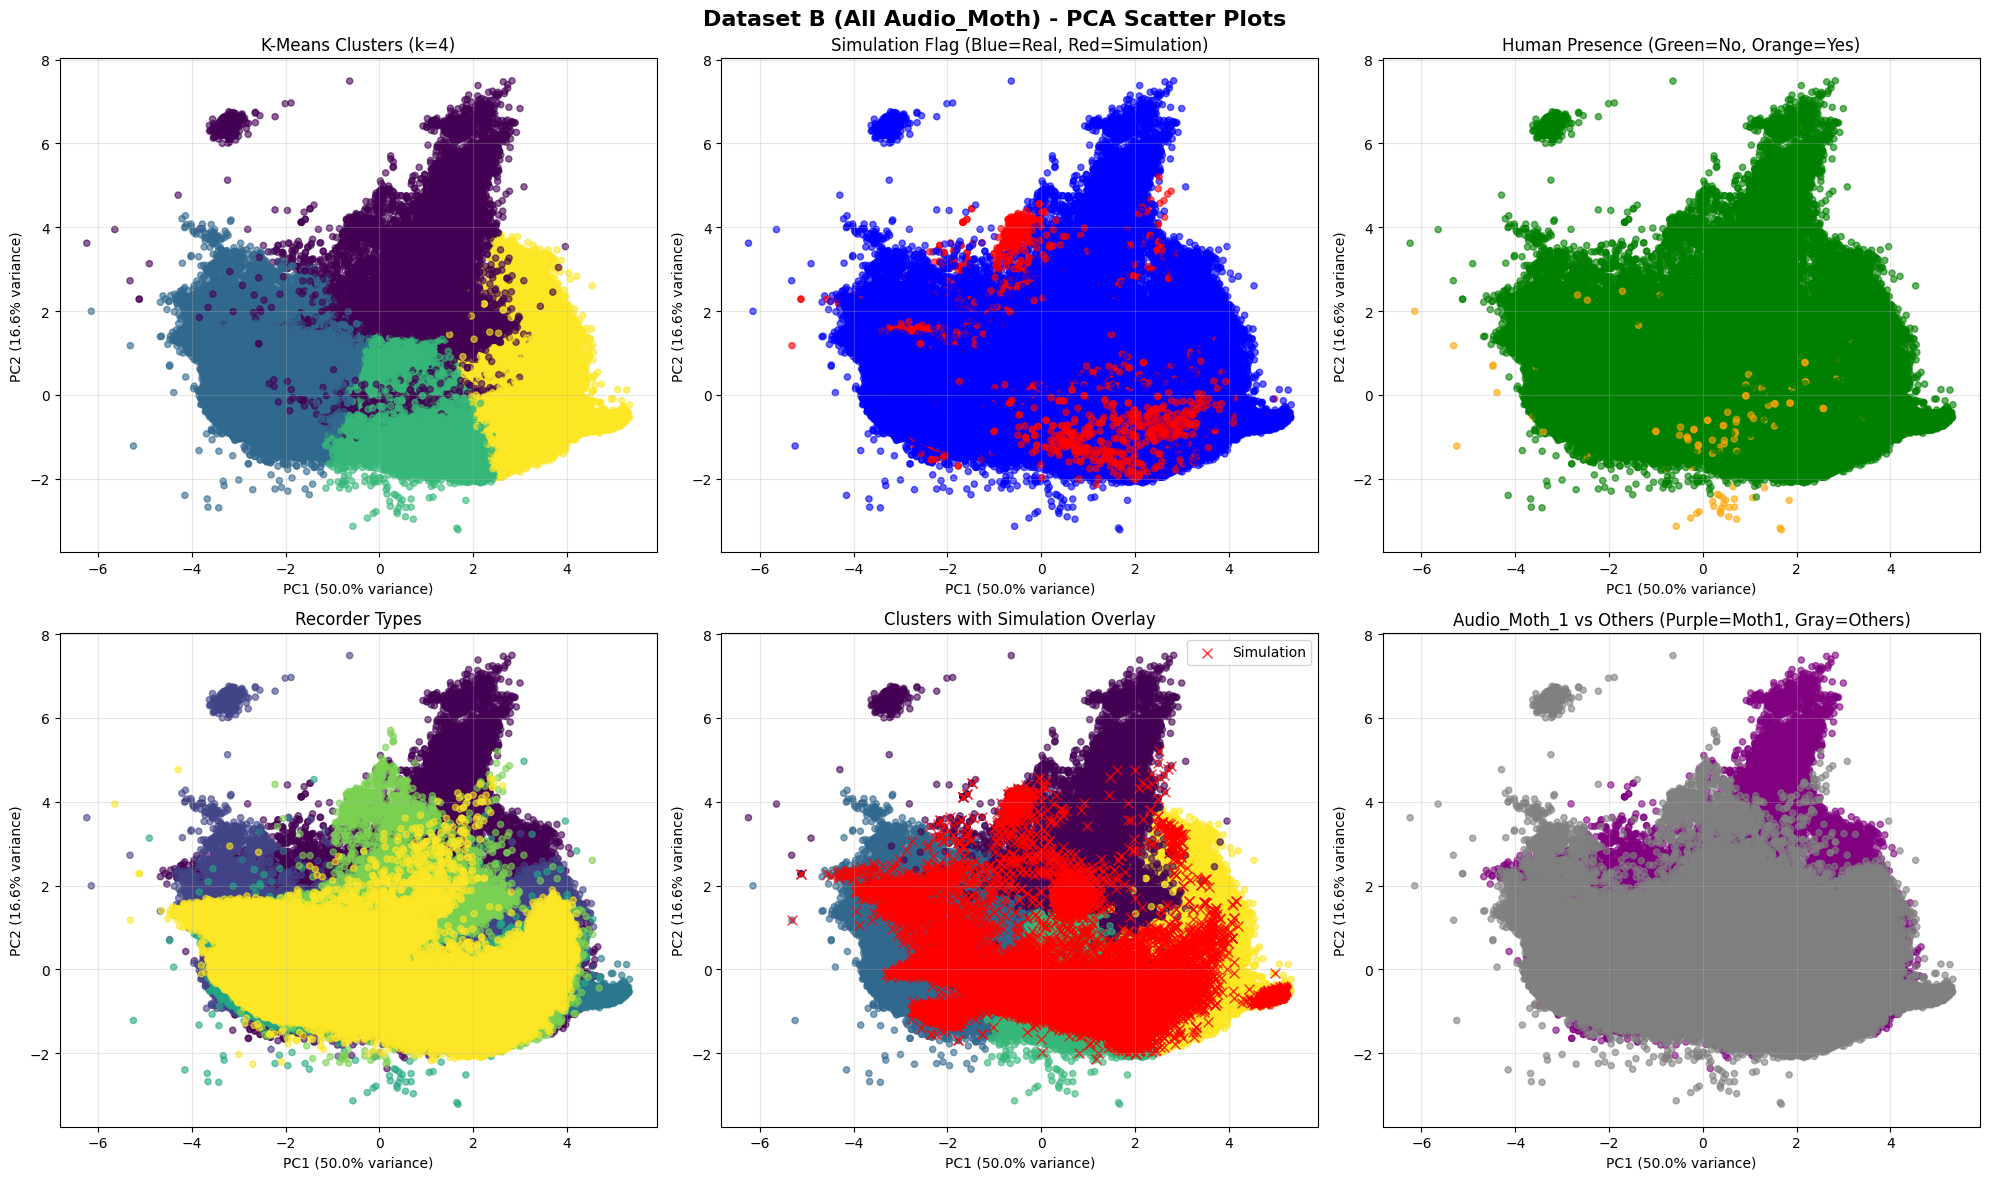

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Dataset B (All Audio_Moth) - PCA Scatter Plots', fontsize=16, fontweight='bold')

pca_viz_B = PCA(n_components=2)
X_B_pca_viz = pca_viz_B.fit_transform(X_B_scaled)

# Plot 1: Clusters
axes[0,0].scatter(X_B_pca_viz[:, 0], X_B_pca_viz[:, 1], c=clusters_B, alpha=0.6, s=20)
axes[0,0].set_title('K-Means Clusters (k=4)')
axes[0,0].set_xlabel(f'PC1 ({pca_viz_B.explained_variance_ratio_[0]:.1%} variance)')
axes[0,0].set_ylabel(f'PC2 ({pca_viz_B.explained_variance_ratio_[1]:.1%} variance)')
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Simulation flag
sim_colors = ['blue' if x == 0 else 'red' for x in df_B_clustered['sim_flag']]
axes[0,1].scatter(X_B_pca_viz[:, 0], X_B_pca_viz[:, 1], c=sim_colors, alpha=0.6, s=20)
axes[0,1].set_title('Simulation Flag (Blue=Real, Red=Simulation)')
axes[0,1].set_xlabel(f'PC1 ({pca_viz_B.explained_variance_ratio_[0]:.1%} variance)')
axes[0,1].set_ylabel(f'PC2 ({pca_viz_B.explained_variance_ratio_[1]:.1%} variance)')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Human presence
human_colors = ['green' if x == 0 else 'orange' for x in df_B_clustered['human_presence']]
axes[0,2].scatter(X_B_pca_viz[:, 0], X_B_pca_viz[:, 1], c=human_colors, alpha=0.6, s=20)
axes[0,2].set_title('Human Presence (Green=No, Orange=Yes)')
axes[0,2].set_xlabel(f'PC1 ({pca_viz_B.explained_variance_ratio_[0]:.1%} variance)')
axes[0,2].set_ylabel(f'PC2 ({pca_viz_B.explained_variance_ratio_[1]:.1%} variance)')
axes[0,2].grid(True, alpha=0.3)

# Plot 4: Recorder types
recorder_colors = pd.Categorical(df_B_clustered['Recorder']).codes
axes[1,0].scatter(X_B_pca_viz[:, 0], X_B_pca_viz[:, 1], c=recorder_colors, alpha=0.6, s=20)
axes[1,0].set_title('Recorder Types')
axes[1,0].set_xlabel(f'PC1 ({pca_viz_B.explained_variance_ratio_[0]:.1%} variance)')
axes[1,0].set_ylabel(f'PC2 ({pca_viz_B.explained_variance_ratio_[1]:.1%} variance)')
axes[1,0].grid(True, alpha=0.3)

# Plot 5: Combined view (clusters with simulation overlay)
scatter = axes[1,1].scatter(X_B_pca_viz[:, 0], X_B_pca_viz[:, 1], 
                           c=clusters_B, alpha=0.6, s=20)
sim_mask = df_B_clustered['sim_flag'] == 1
axes[1,1].scatter(X_B_pca_viz[sim_mask, 0], X_B_pca_viz[sim_mask, 1], 
                 marker='x', s=50, c='red', alpha=0.8, linewidth=1, label='Simulation')
axes[1,1].set_title('Clusters with Simulation Overlay')
axes[1,1].set_xlabel(f'PC1 ({pca_viz_B.explained_variance_ratio_[0]:.1%} variance)')
axes[1,1].set_ylabel(f'PC2 ({pca_viz_B.explained_variance_ratio_[1]:.1%} variance)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

# Plot 6: Audio_Moth_1 vs Others
moth1_mask = df_B_clustered['Recorder'] == 'Audio_Moth_1'
colors_moth1 = ['purple' if x else 'gray' for x in moth1_mask]
axes[1,2].scatter(X_B_pca_viz[:, 0], X_B_pca_viz[:, 1], c=colors_moth1, alpha=0.6, s=20)
axes[1,2].set_title('Audio_Moth_1 vs Others (Purple=Moth1, Gray=Others)')
axes[1,2].set_xlabel(f'PC1 ({pca_viz_B.explained_variance_ratio_[0]:.1%} variance)')
axes[1,2].set_ylabel(f'PC2 ({pca_viz_B.explained_variance_ratio_[1]:.1%} variance)')
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Dataset B shows improved clustering quality (silhouette score 0.330 vs 0.316) and a litle better simulation detection capability with higher and more varied simulation rates across clusters (2.3-3.3% vs 0.5-1.8%). However, human presence detection remains ineffective across all clusters. 

Strong Recorder-Specific Clustering:
Cluster 0: Dominated by Audio_Moth_1 (47%) + Audio_Moth_5 (49%); these two devices cluster together (share specific acoustic conditions?)
Cluster 3: Audio_Moth_3 shows distinct signature (26.5% concentration)
Clusters 1 & 2: More mixed recorder distributions

Key Insight: Acoustic features primarily capture device characteristics rather than biological phenomena, suggesting recorder batch effects dominate the signal over simulation/human detection.

Silhouette (non-noise): 0.409647787785312


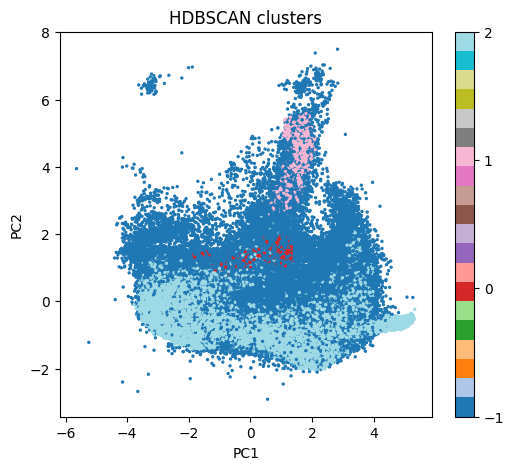

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

feature_cols = [
    'RMS Energy', 'Spectral Centroid', 'Zero Crossing Rate', 'Spectral Bandwidth',
    'Spectral Rolloff (85%)', 'Spectral Flatness', 'Spectral Contrast',
    'Tempo (BPM)', 'Onset Strength'         
]

X = df_comb[feature_cols].dropna()
X_scaled = StandardScaler().fit_transform(X)

n_feats = X_scaled.shape[1]                
pca_model = PCA(n_components=min(10, n_feats),   
                random_state=42)

X_pca = pca_model.fit_transform(X_scaled)  


idx = np.random.choice(len(X_pca), size=150_000, replace=False)
X_sub = X_pca[idx]

clusterer = hdbscan.HDBSCAN(min_cluster_size=800, # tune to control granularity
                            min_samples=20,
                            metric='euclidean',
                            core_dist_n_jobs=-1)
labels = clusterer.fit_predict(X_sub)

mask = labels != -1
if mask.sum() > 1 and len(np.unique(labels[mask])) > 1:
    print("Silhouette (non-noise):",
          silhouette_score(X_sub[mask], labels[mask]))

plt.figure(figsize=(6,5))
scatter = plt.scatter(X_sub[:,0], X_sub[:,1], c=labels, s=2, cmap='tab20')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('HDBSCAN clusters')
plt.colorbar(scatter, ticks=np.unique(labels))
plt.show()


In [22]:
df_sub = df_comb.iloc[idx].copy()         
df_sub['hdbscan_lab'] = labels

df_sub['sim_flag'] = df_sub['sim_name'].notna().astype(int)
df_sub['human_flag'] = (df_sub['Human Activity'] == 'Yes').astype(int)

sim_tab   = pd.crosstab(df_sub['hdbscan_lab'], df_sub['sim_flag'], normalize='index')
human_tab = pd.crosstab(df_sub['hdbscan_lab'], df_sub['human_flag'], normalize='index')

print("Simulation share by cluster (row-%):\n", sim_tab, "\n")
print("Human-presence share by cluster (row-%):\n", human_tab)

from scipy.stats import chi2_contingency
chi_sim   = chi2_contingency(pd.crosstab(df_sub['hdbscan_lab'], df_sub['sim_flag']))
chi_human = chi2_contingency(pd.crosstab(df_sub['hdbscan_lab'], df_sub['human_flag']))

print(f"Sim vs cluster: χ²={chi_sim[0]:.2f}, p={chi_sim[1]:.3g}")
print(f"Human vs cluster: χ²={chi_human[0]:.2f}, p={chi_human[1]:.3g}")


Simulation share by cluster (row-%):
 sim_flag            0         1
hdbscan_lab                    
-1           0.968369  0.031631
 0           1.000000  0.000000
 1           1.000000  0.000000
 2           0.972930  0.027070 

Human-presence share by cluster (row-%):
 human_flag     0
hdbscan_lab     
-1           1.0
 0           1.0
 1           1.0
 2           1.0
Sim vs cluster: χ²=140.88, p=2.44e-30
Human vs cluster: χ²=0.00, p=1


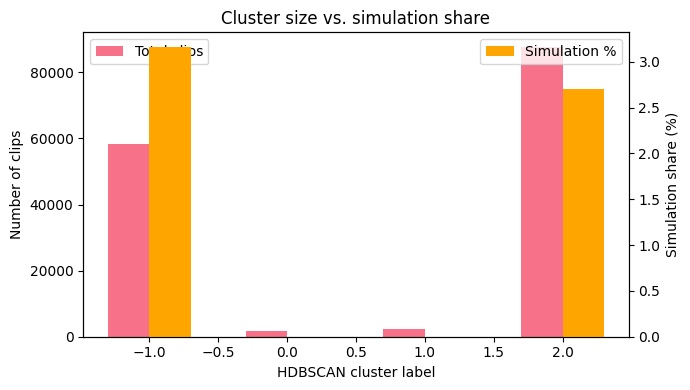

In [23]:

cluster_counts = df_sub['hdbscan_lab'].value_counts().sort_index()
sim_counts     = df_sub[df_sub['sim_flag']==1]['hdbscan_lab'].value_counts().sort_index()
sim_pct        = (sim_counts / cluster_counts).fillna(0)

fig, ax1 = plt.subplots(figsize=(7,4))

ax1.bar(sim_pct.index-0.15, cluster_counts, width=0.3, label='Total clips')
ax1.set_ylabel('Number of clips')
ax1.set_xlabel('HDBSCAN cluster label')

ax2 = ax1.twinx()
ax2.bar(sim_pct.index+0.15, sim_pct*100, width=0.3, color='orange', label='Simulation %')
ax2.set_ylabel('Simulation share (%)')

ax1.set_title('Cluster size vs. simulation share')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()


Simulation clips are not random; they concentrate in the points HDBSCAN calls “noise/outliers” (-1) and in one bona-fide density cluster (2).

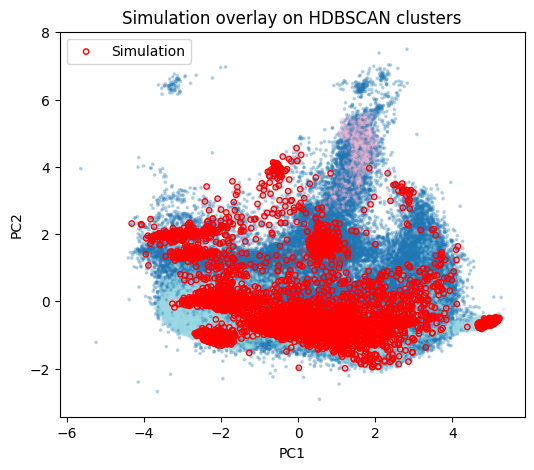

In [24]:
plt.figure(figsize=(6,5))
plt.scatter(X_sub[:,0], X_sub[:,1], c=labels, s=3, cmap='tab20', alpha=0.25)

sim_mask = df_sub['sim_flag']==1
plt.scatter(X_sub[sim_mask,0], X_sub[sim_mask,1],
            facecolors='none', edgecolors='red', s=15, label='Simulation')

plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Simulation overlay on HDBSCAN clusters')
plt.legend()
plt.show()


Visually confirms the bar-chart pattern: simulation audio lives in the “flat, low-PC2” acoustic space and in sparsely populated outskirts that HDBSCAN labels as noise. HDBSCAN offers a more meaningful unsupervised view of the acoustic features and isolates most simulation clips into specific regions, so it’s a constructive step forward.

## Anomaly Detection

### isolation detection

In [ ]:
print("=" * 60)
print("CONTAMINATION PARAMETER TUNING - Dataset A (with train/test split)")
print("=" * 60)

from sklearn.model_selection import train_test_split

X_A_train, X_A_test, y_sim_train, y_sim_test, y_human_train, y_human_test = train_test_split(
    X_A_scaled, df_A['sim_flag'], df_A['human_presence'], 
    test_size=0.3, random_state=42, stratify=df_A['sim_flag']
)

print(f"Train size: {len(X_A_train)}, Test size: {len(X_A_test)}")
print(f"Train sim rate: {y_sim_train.mean():.2%}, Test sim rate: {y_sim_test.mean():.2%}")

contamination_levels = [0.02, 0.03, 0.05, 0.08, 'auto']
results = []

for contamination in contamination_levels:
    print(f"\n--- Contamination = {contamination} ---")
    
    iso_forest = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_estimators=100
    )
    
    iso_forest.fit(X_A_train)
    anomalies_test = iso_forest.predict(X_A_test)
    anomalies_binary_test = (anomalies_test == 1).astype(int)
    
    anomaly_rate = np.mean(anomalies_test == -1)
    print(f"Test anomaly detection rate: {anomaly_rate:.1%}")
    
    from sklearn.metrics import precision_score, recall_score, f1_score
    
    sim_precision = precision_score(y_sim_test, 1-anomalies_binary_test)
    sim_recall = recall_score(y_sim_test, 1-anomalies_binary_test)
    sim_f1 = f1_score(y_sim_test, 1-anomalies_binary_test)
    
    human_precision = precision_score(y_human_test, 1-anomalies_binary_test)
    human_recall = recall_score(y_human_test, 1-anomalies_binary_test)
    human_f1 = f1_score(y_human_test, 1-anomalies_binary_test)
    
    print(f"Simulation  - P: {sim_precision:.3f}, R: {sim_recall:.3f}, F1: {sim_f1:.3f}")
    print(f"Human       - P: {human_precision:.3f}, R: {human_recall:.3f}, F1: {human_f1:.3f}")
    
    results.append({
        'contamination': contamination,
        'anomaly_rate': anomaly_rate,
        'sim_precision': sim_precision,
        'sim_recall': sim_recall,
        'sim_f1': sim_f1,
        'human_precision': human_precision,
        'human_recall': human_recall,
        'human_f1': human_f1
    })

results_df = pd.DataFrame(results)
print(f"\n" + "="*80)
print("SUMMARY TABLE:")
print("="*80)
print(results_df.round(3))

best_sim_f1 = results_df.loc[results_df['sim_f1'].idxmax()]
best_human_f1 = results_df.loc[results_df['human_f1'].idxmax()]

print(f"\nBest for Simulation F1: contamination = {best_sim_f1['contamination']} (F1 = {best_sim_f1['sim_f1']:.3f})")
print(f"Best for Human F1: contamination = {best_human_f1['contamination']} (F1 = {best_human_f1['human_f1']:.3f})")

CONTAMINATION PARAMETER TUNING - Dataset A (with train/test split)
Train size: 90808, Test size: 38919
Train sim rate: 1.37%, Test sim rate: 1.37%

--- Contamination = 0.02 ---
Test anomaly detection rate: 1.9%
Simulation  - P: 0.086, R: 0.122, F1: 0.101
Human       - P: 0.011, R: 0.100, F1: 0.019

--- Contamination = 0.03 ---
Test anomaly detection rate: 2.9%
Simulation  - P: 0.080, R: 0.171, F1: 0.109
Human       - P: 0.011, R: 0.150, F1: 0.020

--- Contamination = 0.05 ---
Test anomaly detection rate: 4.9%
Simulation  - P: 0.068, R: 0.242, F1: 0.106
Human       - P: 0.014, R: 0.325, F1: 0.026

--- Contamination = 0.08 ---
Test anomaly detection rate: 7.9%
Simulation  - P: 0.057, R: 0.329, F1: 0.097
Human       - P: 0.013, R: 0.500, F1: 0.025

--- Contamination = auto ---
Test anomaly detection rate: 13.3%
Simulation  - P: 0.051, R: 0.492, F1: 0.092
Human       - P: 0.011, R: 0.738, F1: 0.023

SUMMARY TABLE:
  contamination  anomaly_rate  sim_precision  sim_recall  sim_f1  \
0       

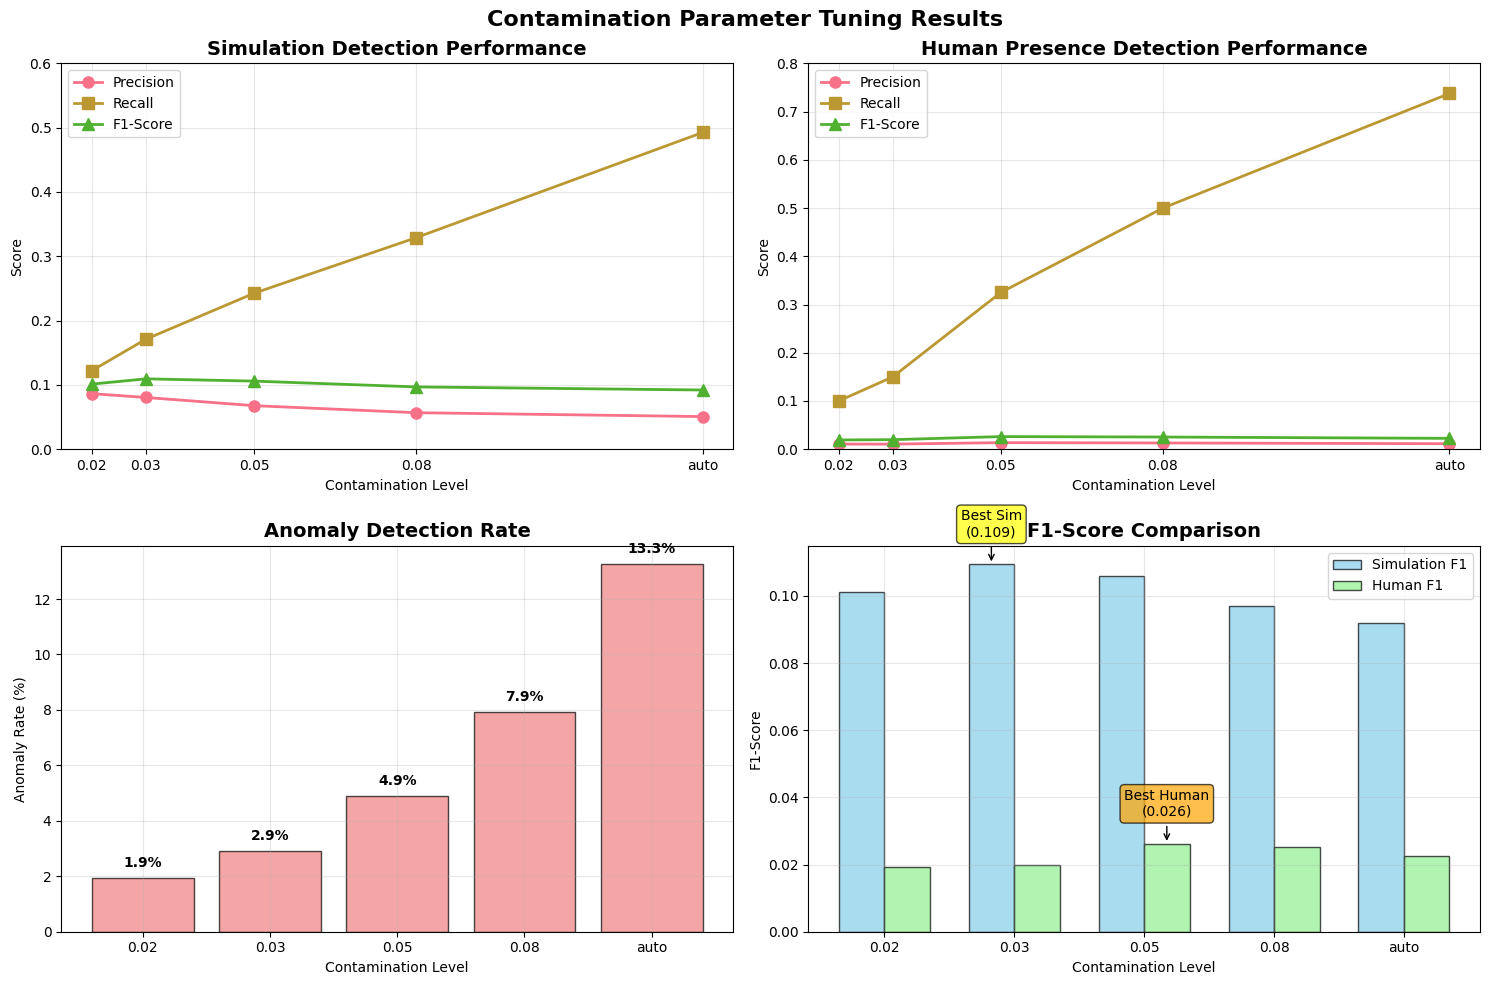

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Contamination Parameter Tuning Results', fontsize=16, fontweight='bold')

contamination_labels = ['0.02', '0.03', '0.05', '0.08', 'auto']
contamination_values = [0.02, 0.03, 0.05, 0.08, 0.133]  # auto = 0.133

axes[0,0].plot(contamination_values, results_df['sim_precision'], 'o-', label='Precision', linewidth=2, markersize=8)
axes[0,0].plot(contamination_values, results_df['sim_recall'], 's-', label='Recall', linewidth=2, markersize=8)
axes[0,0].plot(contamination_values, results_df['sim_f1'], '^-', label='F1-Score', linewidth=2, markersize=8)
axes[0,0].set_title('Simulation Detection Performance', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Contamination Level')
axes[0,0].set_ylabel('Score')
axes[0,0].set_xticks(contamination_values)
axes[0,0].set_xticklabels(contamination_labels)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_ylim(0, 0.6)

axes[0,1].plot(contamination_values, results_df['human_precision'], 'o-', label='Precision', linewidth=2, markersize=8)
axes[0,1].plot(contamination_values, results_df['human_recall'], 's-', label='Recall', linewidth=2, markersize=8)
axes[0,1].plot(contamination_values, results_df['human_f1'], '^-', label='F1-Score', linewidth=2, markersize=8)
axes[0,1].set_title('Human Presence Detection Performance', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Contamination Level')
axes[0,1].set_ylabel('Score')
axes[0,1].set_xticks(contamination_values)
axes[0,1].set_xticklabels(contamination_labels)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)
axes[0,1].set_ylim(0, 0.8)

axes[1,0].bar(contamination_labels, results_df['anomaly_rate']*100, 
              alpha=0.7, color='lightcoral', edgecolor='black')
axes[1,0].set_title('Anomaly Detection Rate', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Contamination Level')
axes[1,0].set_ylabel('Anomaly Rate (%)')
axes[1,0].grid(True, alpha=0.3)
for i, v in enumerate(results_df['anomaly_rate']*100):
    axes[1,0].text(i, v + 0.3, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')

x_pos = np.arange(len(contamination_labels))
width = 0.35
axes[1,1].bar(x_pos - width/2, results_df['sim_f1'], width, 
              label='Simulation F1', alpha=0.7, color='skyblue', edgecolor='black')
axes[1,1].bar(x_pos + width/2, results_df['human_f1'], width, 
              label='Human F1', alpha=0.7, color='lightgreen', edgecolor='black')
axes[1,1].set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Contamination Level')
axes[1,1].set_ylabel('F1-Score')
axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels(contamination_labels)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

best_sim_idx = results_df['sim_f1'].idxmax()
best_human_idx = results_df['human_f1'].idxmax()
axes[1,1].annotate(f'Best Sim\n({results_df.iloc[best_sim_idx]["sim_f1"]:.3f})', 
                   xy=(best_sim_idx - width/2, results_df.iloc[best_sim_idx]['sim_f1']), 
                   xytext=(0, 20), textcoords='offset points', ha='center',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
                   arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
axes[1,1].annotate(f'Best Human\n({results_df.iloc[best_human_idx]["human_f1"]:.3f})', 
                   xy=(best_human_idx + width/2, results_df.iloc[best_human_idx]['human_f1']), 
                   xytext=(0, 20), textcoords='offset points', ha='center',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='orange', alpha=0.7),
                   arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

plt.tight_layout()
plt.show()



The contamination tuning reveals a fundamental limitation in acoustic feature discriminability for rare ecological events. While contamination=0.03 achieves the best simulation F1-score (0.109), the overall performance remains modest, suggesting that spectral and temporal features alone may be insufficient for reliable detection. The precision-recall trade-off is steep - higher contamination captures more true positives but introduces excessive false positives. 

Auto achieves higher recall (49% vs 17%) but creates 5184 false alarms - impractical for manual review. Contamination=0.03 produces only 1129 false alarms while maintaining better F1-score (0.109 vs 0.092).

In [ ]:
print("=" * 70)
print("CONTAMINATION PARAMETER TUNING - Dataset B")
print("=" * 70)

print(f"Dataset B characteristics:")
print(f"- Simulation rate: {y_sim_B_test.mean():.2%}")
print(f"- Human presence rate: {y_human_B_test.mean():.2%}")
print(f"- Combined rare events: {(y_sim_B_test.mean() + y_human_B_test.mean()):.2%}")

contamination_levels_B = [0.02, 0.03, 0.04, 0.05, 0.07, 'auto']
results_B = []

for contamination in contamination_levels_B:
    print(f"\n--- Contamination = {contamination} ---")
    
    iso_forest = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_estimators=100
    )
    
    iso_forest.fit(X_B_train)
    anomalies = iso_forest.predict(X_B_test)
    anomalies_binary = (anomalies == 1).astype(int)
    
    anomaly_rate = np.mean(anomalies == -1)
    print(f"Test anomaly detection rate: {anomaly_rate:.1%}")
    
    sim_precision = precision_score(y_sim_B_test, 1-anomalies_binary)
    sim_recall = recall_score(y_sim_B_test, 1-anomalies_binary)
    sim_f1 = f1_score(y_sim_B_test, 1-anomalies_binary)
    
    human_precision = precision_score(y_human_B_test, 1-anomalies_binary)
    human_recall = recall_score(y_human_B_test, 1-anomalies_binary)
    human_f1 = f1_score(y_human_B_test, 1-anomalies_binary)
    
    print(f"Simulation  - P: {sim_precision:.3f}, R: {sim_recall:.3f}, F1: {sim_f1:.3f}")
    print(f"Human       - P: {human_precision:.3f}, R: {human_recall:.3f}, F1: {human_f1:.3f}")
    
    results_B.append({
        'contamination': contamination,
        'anomaly_rate': anomaly_rate,
        'sim_precision': sim_precision,
        'sim_recall': sim_recall,
        'sim_f1': sim_f1,
        'human_precision': human_precision,
        'human_recall': human_recall,
        'human_f1': human_f1
    })

results_B_df = pd.DataFrame(results_B)
print(f"\n" + "="*80)
print("SUMMARY TABLE - Dataset B:")
print("="*80)
print(results_B_df.round(3))

best_sim_f1_B = results_B_df.loc[results_B_df['sim_f1'].idxmax()]
best_human_f1_B = results_B_df.loc[results_B_df['human_f1'].idxmax()]

print(f"\nBest for Simulation F1: contamination = {best_sim_f1_B['contamination']} (F1 = {best_sim_f1_B['sim_f1']:.3f})")
print(f"Best for Human F1: contamination = {best_human_f1_B['contamination']} (F1 = {best_human_f1_B['human_f1']:.3f})")

dataset_a_performance = {'sim_f1': 0.109, 'human_f1': 0.020}
best_B_sim_f1 = results_B_df['sim_f1'].max()
best_B_human_f1 = results_B_df['human_f1'].max()

print(f"\n" + "="*60)
print("OPTIMAL PERFORMANCE COMPARISON:")
print("="*60)
print(f"                Dataset A (0.03)    Dataset B (optimal)    Change")
print(f"Best Sim F1:    {dataset_a_performance['sim_f1']:.3f}           {best_B_sim_f1:.3f}            {best_B_sim_f1-dataset_a_performance['sim_f1']:+.3f}")
print(f"Best Human F1:  {dataset_a_performance['human_f1']:.3f}           {best_B_human_f1:.3f}            {best_B_human_f1-dataset_a_performance['human_f1']:+.3f}")

CONTAMINATION PARAMETER TUNING - Dataset B
Dataset B characteristics:
- Simulation rate: 2.79%
- Human presence rate: 0.11%
- Combined rare events: 2.90%

--- Contamination = 0.02 ---
Test anomaly detection rate: 2.0%
Simulation  - P: 0.044, R: 0.032, F1: 0.037
Human       - P: 0.004, R: 0.068, F1: 0.007

--- Contamination = 0.03 ---
Test anomaly detection rate: 3.0%
Simulation  - P: 0.039, R: 0.041, F1: 0.040
Human       - P: 0.003, R: 0.086, F1: 0.006

--- Contamination = 0.04 ---
Test anomaly detection rate: 4.0%
Simulation  - P: 0.037, R: 0.053, F1: 0.044
Human       - P: 0.003, R: 0.100, F1: 0.005

--- Contamination = 0.05 ---
Test anomaly detection rate: 5.0%
Simulation  - P: 0.037, R: 0.065, F1: 0.047
Human       - P: 0.003, R: 0.122, F1: 0.005

--- Contamination = 0.07 ---
Test anomaly detection rate: 7.1%
Simulation  - P: 0.038, R: 0.095, F1: 0.054
Human       - P: 0.003, R: 0.158, F1: 0.005

--- Contamination = auto ---
Test anomaly detection rate: 16.1%
Simulation  - P: 0.03

DATASET B - OPTIMAL CONTAMINATION RESULTS
Optimal contamination: auto
Test samples: 198217
Detected anomalies: 31827 (16.1%)

=== SIMULATION DETECTION (Optimal) ===
Confusion Matrix:
                 Predicted
Actual           Normal  Anomaly
Real            162064    30626
Simulation        4326     1201

Optimal Metrics:
Precision: 0.038
Recall:    0.217
F1-Score:  0.064

=== HUMAN PRESENCE DETECTION (Optimal) ===
Confusion Matrix:
                 Predicted
Actual           Normal  Anomaly
No Human        166267    31729
Human Present      123       98

Optimal Metrics:
Precision: 0.003
Recall:    0.443
F1-Score:  0.006


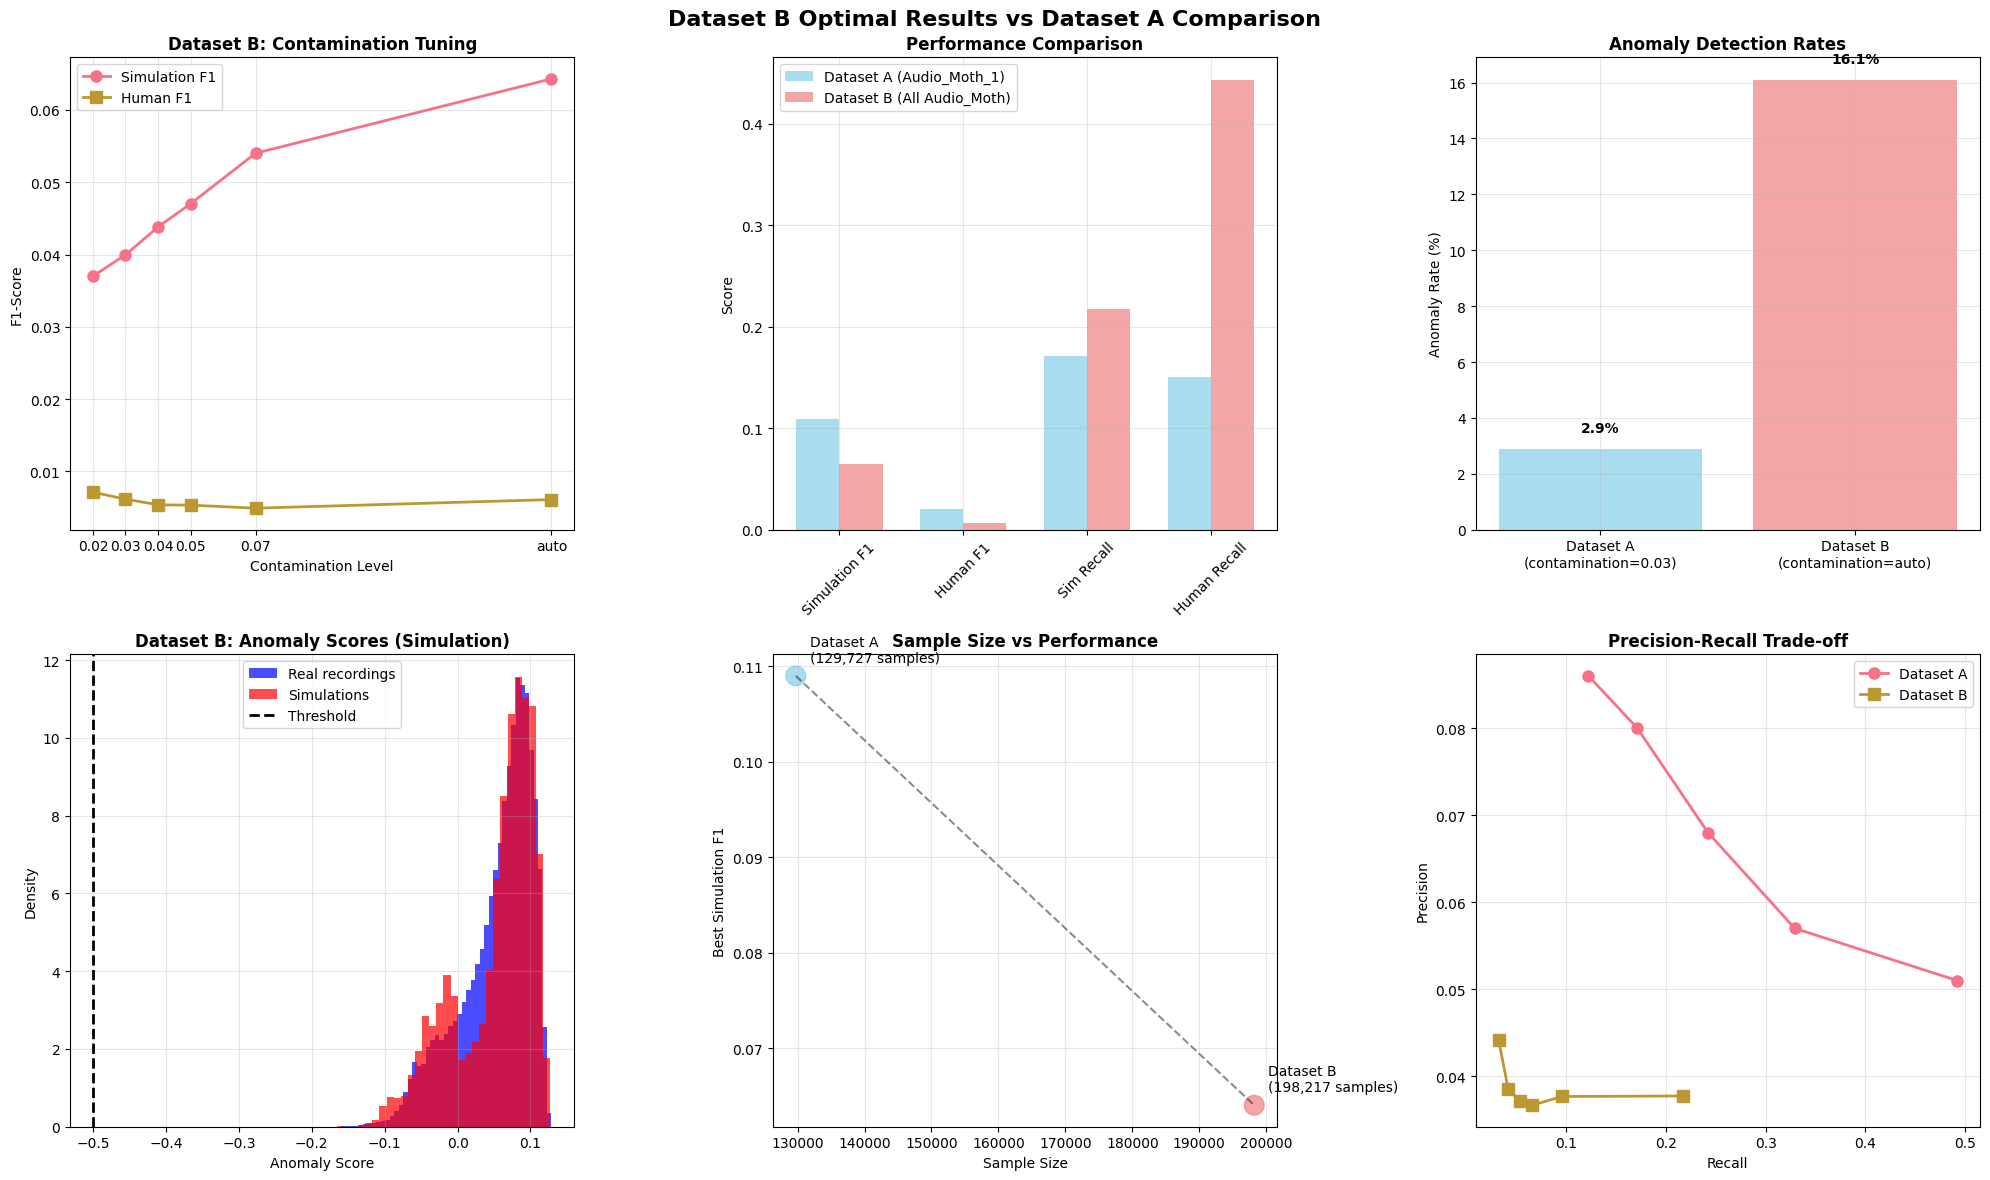

In [ ]:
print("=" * 70)
print("DATASET B - OPTIMAL CONTAMINATION RESULTS")
print("=" * 70)

optimal_iso_forest_B = IsolationForest(
    contamination='auto',
    random_state=42,
    n_estimators=100
)

optimal_iso_forest_B.fit(X_B_train)
optimal_anomalies_B = optimal_iso_forest_B.predict(X_B_test)
optimal_anomalies_B_binary = (optimal_anomalies_B == 1).astype(int)

print(f"Optimal contamination: auto")
print(f"Test samples: {len(optimal_anomalies_B)}")
print(f"Detected anomalies: {np.sum(optimal_anomalies_B == -1)} ({np.mean(optimal_anomalies_B == -1):.1%})")

print(f"\n=== SIMULATION DETECTION (Optimal) ===")
sim_cm_opt = confusion_matrix(y_sim_B_test, 1-optimal_anomalies_B_binary)
print("Confusion Matrix:")
print("                 Predicted")
print("Actual           Normal  Anomaly")
print(f"Real           {sim_cm_opt[0,0]:7d}  {sim_cm_opt[0,1]:7d}")
print(f"Simulation     {sim_cm_opt[1,0]:7d}  {sim_cm_opt[1,1]:7d}")

sim_precision_opt = precision_score(y_sim_B_test, 1-optimal_anomalies_B_binary)
sim_recall_opt = recall_score(y_sim_B_test, 1-optimal_anomalies_B_binary)
sim_f1_opt = f1_score(y_sim_B_test, 1-optimal_anomalies_B_binary)

print(f"\nOptimal Metrics:")
print(f"Precision: {sim_precision_opt:.3f}")
print(f"Recall:    {sim_recall_opt:.3f}")
print(f"F1-Score:  {sim_f1_opt:.3f}")

print(f"\n=== HUMAN PRESENCE DETECTION (Optimal) ===")
human_cm_opt = confusion_matrix(y_human_B_test, 1-optimal_anomalies_B_binary)
print("Confusion Matrix:")
print("                 Predicted")
print("Actual           Normal  Anomaly")
print(f"No Human       {human_cm_opt[0,0]:7d}  {human_cm_opt[0,1]:7d}")
print(f"Human Present  {human_cm_opt[1,0]:7d}  {human_cm_opt[1,1]:7d}")

human_precision_opt = precision_score(y_human_B_test, 1-optimal_anomalies_B_binary)
human_recall_opt = recall_score(y_human_B_test, 1-optimal_anomalies_B_binary)
human_f1_opt = f1_score(y_human_B_test, 1-optimal_anomalies_B_binary)

print(f"\nOptimal Metrics:")
print(f"Precision: {human_precision_opt:.3f}")
print(f"Recall:    {human_recall_opt:.3f}")
print(f"F1-Score:  {human_f1_opt:.3f}")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Dataset B Optimal Results vs Dataset A Comparison', fontsize=16, fontweight='bold')

# Plot 1: Contamination tuning results for Dataset B
contamination_values_B = [0.02, 0.03, 0.04, 0.05, 0.07, 0.161]  # auto = 0.161
contamination_labels_B = ['0.02', '0.03', '0.04', '0.05', '0.07', 'auto']

axes[0,0].plot(contamination_values_B, results_B_df['sim_f1'], 'o-', linewidth=2, markersize=8, label='Simulation F1')
axes[0,0].plot(contamination_values_B, results_B_df['human_f1'], 's-', linewidth=2, markersize=8, label='Human F1')
axes[0,0].set_title('Dataset B: Contamination Tuning', fontweight='bold')
axes[0,0].set_xlabel('Contamination Level')
axes[0,0].set_ylabel('F1-Score')
axes[0,0].set_xticks(contamination_values_B)
axes[0,0].set_xticklabels(contamination_labels_B)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Dataset A vs Dataset B performance comparison
categories = ['Simulation F1', 'Human F1', 'Sim Recall', 'Human Recall']
dataset_a_scores = [0.109, 0.020, 0.171, 0.150]  
dataset_b_scores = [sim_f1_opt, human_f1_opt, sim_recall_opt, human_recall_opt]

x_pos = np.arange(len(categories))
width = 0.35
axes[0,1].bar(x_pos - width/2, dataset_a_scores, width, label='Dataset A (Audio_Moth_1)', alpha=0.7, color='skyblue')
axes[0,1].bar(x_pos + width/2, dataset_b_scores, width, label='Dataset B (All Audio_Moth)', alpha=0.7, color='lightcoral')
axes[0,1].set_title('Performance Comparison', fontweight='bold')
axes[0,1].set_ylabel('Score')
axes[0,1].set_xticks(x_pos)
axes[0,1].set_xticklabels(categories, rotation=45)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Anomaly detection rates
datasets = ['Dataset A\n(contamination=0.03)', 'Dataset B\n(contamination=auto)']
anomaly_rates = [2.9, 16.1]  
axes[0,2].bar(datasets, anomaly_rates, alpha=0.7, color=['skyblue', 'lightcoral'])
axes[0,2].set_title('Anomaly Detection Rates', fontweight='bold')
axes[0,2].set_ylabel('Anomaly Rate (%)')
for i, v in enumerate(anomaly_rates):
    axes[0,2].text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[0,2].grid(True, alpha=0.3)

# Plot 4: Anomaly score distributions for Dataset B
anomaly_scores_B = optimal_iso_forest_B.decision_function(X_B_test)
sim_normal_scores_B = anomaly_scores_B[y_sim_B_test == 0]
sim_anomaly_scores_B = anomaly_scores_B[y_sim_B_test == 1]

axes[1,0].hist(sim_normal_scores_B, bins=50, alpha=0.7, label='Real recordings', color='blue', density=True)
axes[1,0].hist(sim_anomaly_scores_B, bins=30, alpha=0.7, label='Simulations', color='red', density=True)
axes[1,0].axvline(optimal_iso_forest_B.offset_, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[1,0].set_title('Dataset B: Anomaly Scores (Simulation)', fontweight='bold')
axes[1,0].set_xlabel('Anomaly Score')
axes[1,0].set_ylabel('Density')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 5: Sample size impact
sample_sizes = [129727, 198217]  
best_f1_scores = [0.109, 0.064] 
axes[1,1].scatter(sample_sizes, best_f1_scores, s=200, alpha=0.7, c=['skyblue', 'lightcoral'])
axes[1,1].plot(sample_sizes, best_f1_scores, 'k--', alpha=0.5)
for i, (size, score) in enumerate(zip(sample_sizes, best_f1_scores)):
    dataset_name = 'Dataset A' if i == 0 else 'Dataset B'
    axes[1,1].annotate(f'{dataset_name}\n({size:,} samples)', 
                      (size, score), xytext=(10, 10), textcoords='offset points')
axes[1,1].set_title('Sample Size vs Performance', fontweight='bold')
axes[1,1].set_xlabel('Sample Size')
axes[1,1].set_ylabel('Best Simulation F1')
axes[1,1].grid(True, alpha=0.3)

# Plot 6: Precision-Recall trade-off comparison
precisions_A = [0.086, 0.080, 0.068, 0.057, 0.051]  
recalls_A = [0.122, 0.171, 0.242, 0.329, 0.492]
precisions_B = results_B_df['sim_precision'].tolist()
recalls_B = results_B_df['sim_recall'].tolist()

axes[1,2].plot(recalls_A, precisions_A, 'o-', label='Dataset A', linewidth=2, markersize=8)
axes[1,2].plot(recalls_B, precisions_B, 's-', label='Dataset B', linewidth=2, markersize=8)
axes[1,2].set_title('Precision-Recall Trade-off', fontweight='bold')
axes[1,2].set_xlabel('Recall')
axes[1,2].set_ylabel('Precision')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Open area recordings （moth1） enable better anomaly detection because environmental consistency allows biological signals to emerge above device noise. Multi-recorder data paradoxically hurts performance despite 5x more samples, as device variations dominate over rare biological events.

## Boosting

### XGBoost with weight on positives


========== SIMULATION DETECTION ==========
Positive ratio (train): 1.37% | pos_weight used: 72.12683201803833

-- Default threshold 0.50 --
              precision    recall  f1-score   support

           0      0.999     0.950     0.974     31988
           1      0.207     0.935     0.339       444

    accuracy                          0.950     32432
   macro avg      0.603     0.943     0.657     32432
weighted avg      0.988     0.950     0.965     32432


Best threshold among (0.5, 0.4, 0.35, 0.3): 0.5  (F1 = 0.339)
Confusion matrix @ best_thr:
        Pred 0  Pred 1
True 0   30400    1588
True 1      29     415
AUC: 0.987


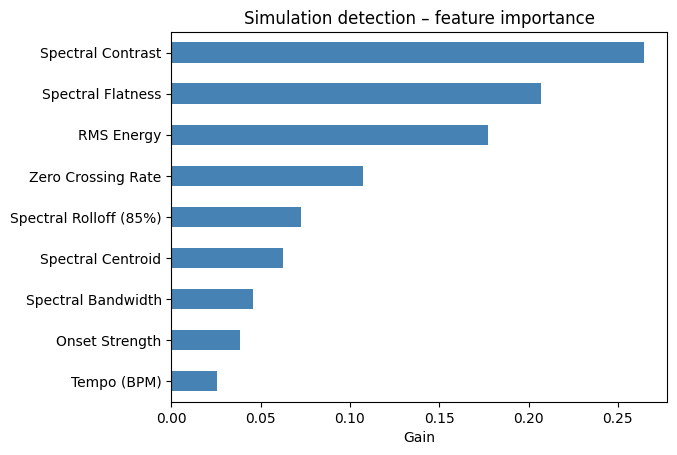


========== HUMAN-ACTIVITY DETECTION ==========
Positive ratio (train): 0.19% | pos_weight used: 513.7896825396825

-- Default threshold 0.50 --
              precision    recall  f1-score   support

           0      1.000     0.998     0.999     32369
           1      0.523     0.905     0.663        63

    accuracy                          0.998     32432
   macro avg      0.761     0.952     0.831     32432
weighted avg      0.999     0.998     0.998     32432


Best threshold among (0.5, 0.45, 0.4): 0.5  (F1 = 0.663)
Confusion matrix @ best_thr:
        Pred 0  Pred 1
True 0   32317      52
True 1       6      57
AUC: 0.998


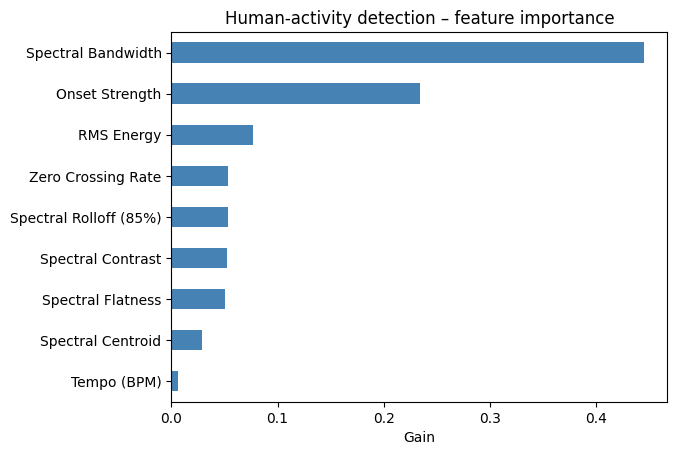

   Optimal threshold – Simulation: 0.5 | Human: 0.5


In [ ]:
X  = X_A                               
yS = df_A["sim_flag"].values  # simulation label
yH = df_A["human_presence"].values# human-activity label

def train_xgb_binary(X, y, label_name, pos_weight=None, thresholds=(0.5, 0.4, 0.3)):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    clf = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=pos_weight,
        n_jobs=-1,
        random_state=42,
    )
    clf.fit(X_tr, y_tr)
    proba = clf.predict_proba(X_te)[:, 1]

    print(f"\n========== {label_name.upper()} ==========")
    print(f"Positive ratio (train): {y.mean():.2%} | pos_weight used: {pos_weight}")

    print("\n-- Default threshold 0.50 --")
    preds = (proba >= 0.5)
    print(classification_report(y_te, preds, digits=3))

    best_f1 = 0
    best_thr = 0.5
    for thr in thresholds:
        preds = (proba >= thr)
        f1 = f1_score(y_te, preds)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    print(f"\nBest threshold among {thresholds}: {best_thr}  (F1 = {best_f1:.3f})")

    preds = (proba >= best_thr)
    cm = confusion_matrix(y_te, preds)
    print("Confusion matrix @ best_thr:")
    print(pd.DataFrame(cm, index=['True 0', 'True 1'],
                            columns=['Pred 0', 'Pred 1']))
    print(f"AUC: {roc_auc_score(y_te, proba):.3f}")

    imp = pd.Series(clf.feature_importances_, index=all_feature_cols).sort_values()
    imp.plot.barh(color="steelblue")
    plt.title(f"{label_name} – feature importance")
    plt.xlabel("Gain")
    plt.show()

    return clf, best_thr

pos_w_sim = (yS == 0).sum() / (yS == 1).sum()
sim_model, sim_thr = train_xgb_binary(
    X, yS, label_name="Simulation detection",
    pos_weight=pos_w_sim,
    thresholds=(0.50, 0.40, 0.35, 0.30)
)

pos_w_hum = (yH == 0).sum() / (yH == 1).sum()
hum_model, hum_thr = train_xgb_binary(
    X, yH, label_name="Human-activity detection",
    pos_weight=pos_w_hum,
    thresholds=(0.50, 0.45, 0.40)
)

print(f"   Optimal threshold – Simulation: {sim_thr} | Human: {hum_thr}")


Two binary models were trained on 9 acoustic features only. Class-imbalance was compensated with scale_pos_weight; predictions were then converted to 0 / 1 with a 0.50 probability threshold.

Key test metrics:
Simulation AUC 0.987 Precision 0.21 Recall 0.94 F1 0.34
Human AUC 0.998 Precision 0.52 Recall 0.91 F1 0.66

Spectral-shape features dominate both tasks, but in different ways: Playback simulations are flagged mainly by Spectral Contrast, Flatness, RMS Energy. Human presence is dominated by Spectral Bandwidth plus transient strength (Onset Strength).

Lowering the decision threshold would further raise recall, but precision would drop; 0.50 already maximises F1 on this data.

Benefits: Recall is excellent (≥ 0.9) for both objectives after class weighting.

Limitations: Precision on simulations is still low (≈ 0.21) – 1 in 5 alerts is true; post-filtering may be required if false-positives are costly.


========== SIMULATION DETECTION  (All Audio_Moth) ==========
Positive ratio: 2.79% | pos_weight = 34.86

Threshold 0.50 gives best F1 = 0.214
              precision    recall  f1-score   support

           0      0.996     0.818     0.898    160575
           1      0.122     0.879     0.214      4606

    accuracy                          0.820    165181
   macro avg      0.559     0.849     0.556    165181
weighted avg      0.971     0.820     0.879    165181

        Pred 0  Pred 1
True 0  131319   29256
True 1     556    4050
AUC  = 0.928


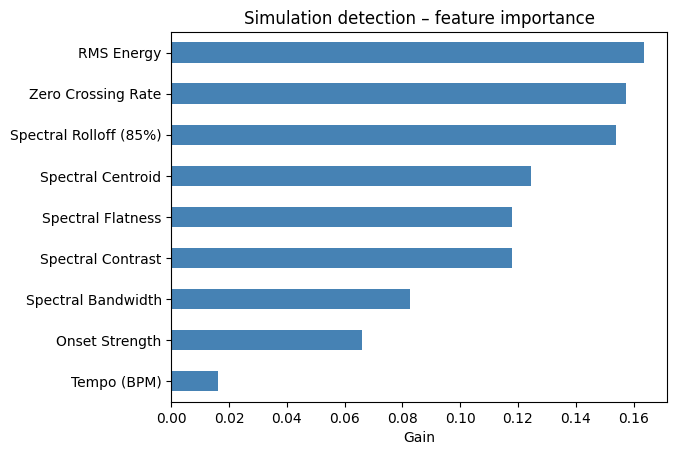


========== HUMAN-ACTIVITY DETECTION  (All Audio_Moth) ==========
Positive ratio: 0.11% | pos_weight = 869.52

Threshold 0.50 gives best F1 = 0.311
              precision    recall  f1-score   support

           0      1.000     0.995     0.998    164991
           1      0.187     0.932     0.311       190

    accuracy                          0.995    165181
   macro avg      0.593     0.963     0.654    165181
weighted avg      0.999     0.995     0.997    165181

        Pred 0  Pred 1
True 0  164220     771
True 1      13     177
AUC  = 0.998


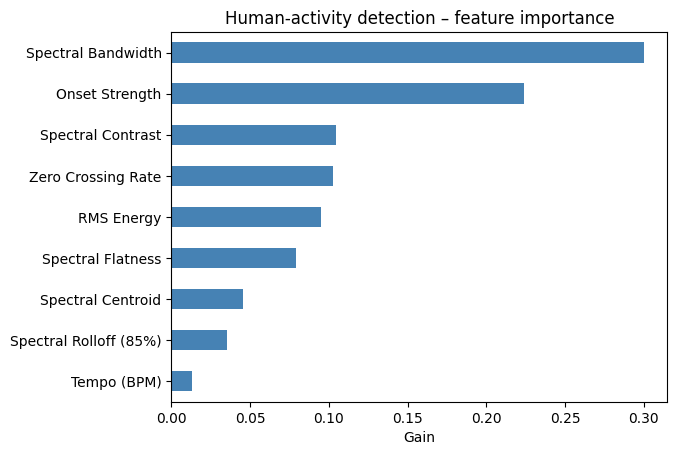


✓ Training on **all** Audio_Moth recorders finished.
  Optimal thresholds – Simulation: 0.5 | Human: 0.5


In [ ]:
def train_xgb_binary(X, y, label_name, pos_weight=None, thr_list=(0.5, 0.4, 0.3)):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )
    clf = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=pos_weight,
        n_jobs=-1,
        random_state=42
    )
    clf.fit(X_tr, y_tr)
    proba = clf.predict_proba(X_te)[:, 1]

    print(f"\n========== {label_name.upper()}  (All Audio_Moth) ==========")
    print(f"Positive ratio: {y.mean():.2%} | pos_weight = {pos_weight:.2f}")

    best_f1, best_thr = 0, 0.5
    for thr in thr_list:
        preds = proba >= thr
        f1 = f1_score(y_te, preds)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr

    preds = proba >= best_thr
    print(f"\nThreshold {best_thr:.2f} gives best F1 = {best_f1:.3f}")
    print(classification_report(y_te, preds, digits=3))
    print(pd.DataFrame(
        confusion_matrix(y_te, preds),
        index=['True 0', 'True 1'], columns=['Pred 0', 'Pred 1']
    ))
    print(f"AUC  = {roc_auc_score(y_te, proba):.3f}")


    imp = pd.Series(clf.feature_importances_, index=all_feature_cols).sort_values()
    imp.plot.barh(color="steelblue")
    plt.title(f"{label_name} – feature importance")
    plt.xlabel("Gain")
    plt.show()

    return clf, best_thr

y_sim_all  = df_B["sim_flag"].values
y_hum_all  = df_B["human_presence"].values
w_sim = (y_sim_all == 0).sum() / (y_sim_all == 1).sum()
sim_model_all, sim_thr_all = train_xgb_binary(
    X_B, y_sim_all, "Simulation detection", pos_weight=w_sim,
    thr_list=(0.50, 0.45, 0.40, 0.35, 0.30)
)
w_hum = (y_hum_all == 0).sum() / (y_hum_all == 1).sum()
hum_model_all, hum_thr_all = train_xgb_binary(
    X_B, y_hum_all, "Human-activity detection", pos_weight=w_hum,
    thr_list=(0.50, 0.45, 0.40)
)

print("\n✓ Training on **all** Audio_Moth recorders finished.")
print(f"  Optimal thresholds – Simulation: {sim_thr_all} | Human: {hum_thr_all}")


Simulation now relies most on RMS Energy, ZCR, Spectral Rolloff & Centroid – energy shape differs markedly across playback clips and devices.

Human detection is still driven by Spectral Bandwidth and Onset Strength, but weight is spread more evenly; transient cues remain critical.

Recall stays very high across all six recorders, confirming the 9-feature set generalises.

Precision drops, especially for simulations (≈ 12 % ⇒ 1 true in 8 false alarms).

In short: the Isolation-Forest layer trades recall for precision. It is only beneficial if we value precision far more than completeness. Otherwise, tuning the XGB probability threshold alone is simpler and causes a gentler recall drop.

In [ ]:
for t in [0.90, 0.85, 0.80, 0.70, 0.60]:
    i = np.abs(thr - t).argmin()
    print(f"thr={thr[i]:.2f} | P={prec[i]:.3f} | R={rec[i]:.3f}")

thr=0.90 | P=0.501 | R=0.698
thr=0.85 | P=0.448 | R=0.773
thr=0.80 | P=0.405 | R=0.824
thr=0.70 | P=0.330 | R=0.876
thr=0.60 | P=0.289 | R=0.912


In [32]:
import xgboost
print(xgboost.__version__)

3.0.2


### LightGBM

[LightGBM] [Info] Number of positive: 1330, number of negative: 95965
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2136
[LightGBM] [Info] Number of data points in the train set: 97295, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.013670 -> initscore=-4.278805
[LightGBM] [Info] Start training from score -4.278805
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.0585492

Chosen threshold: 0.043  |  Recall 0.955  |  Precision 0.097

=== LightGBM – simulation detection (Audio-Moth 1) ===
              precision    recall  f1-score   support

           0      1.000     0.849     0.918     31988
           1      0.082     0.973     0.151       444

    accuracy                          0.850     32432
   macro avg      0.541     0.911   

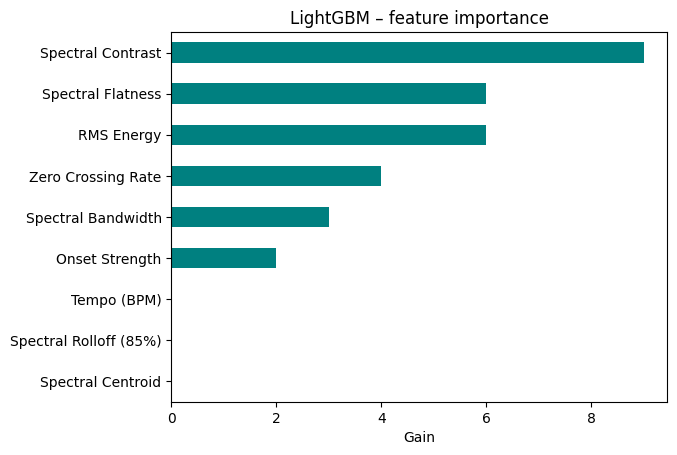

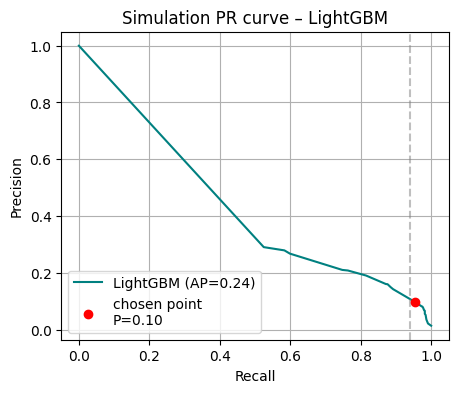

In [ ]:
y_sim = df_A["sim_flag"].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_A, y_sim, test_size=0.25, random_state=42, stratify=y_sim
)

pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

train_ds = lgb.Dataset(X_tr, label=y_tr)
valid_ds = lgb.Dataset(X_te, label=y_te, reference=train_ds)

params = dict(
    objective        = "binary",
    metric           = "binary_logloss",
    learning_rate    = 0.05,
    num_leaves       = 31,
    max_depth        = -1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = pos_weight,   
    seed             = 42,
)

callbacks = [
    lgb.early_stopping(stopping_rounds=50),
    lgb.log_evaluation(period=100)
]

model = lgb.train(
    params,
    train_ds,
    num_boost_round=800,
    valid_sets=[valid_ds],
    callbacks=callbacks
)

proba_te = model.predict(X_te, num_iteration=model.best_iteration)

prec, rec, thr = precision_recall_curve(y_te, proba_te)
target_recall  = 0.94
rec_cut  = rec[1:]                            
prec_cut = prec[1:]
thr_cut  = thr

mask     = rec_cut >= target_recall
best_idx = np.argmax(prec_cut[mask])           
best_thr = thr_cut[mask][best_idx]
best_prec= prec_cut[mask][best_idx]
best_rec = rec_cut[mask][best_idx]

print(f"\nChosen threshold: {best_thr:.3f}  |  Recall {best_rec:.3f}  |  Precision {best_prec:.3f}")

y_pred = proba_te >= best_thr
print("\n=== LightGBM – simulation detection (Audio-Moth 1) ===")
print(classification_report(y_te, y_pred, digits=3))
print(pd.DataFrame(confusion_matrix(y_te, y_pred),
                   index=["True 0","True 1"], columns=["Pred 0","Pred 1"]))
print(f"AUC: {roc_auc_score(y_te, proba_te):.3f}")

imp = pd.Series(model.feature_importance(), index=all_feature_cols)\
        .sort_values()
imp.plot.barh(color="teal")
plt.title("LightGBM – feature importance"); plt.xlabel("Gain"); plt.show()

from sklearn.metrics import average_precision_score
ap = average_precision_score(y_te, proba_te)

plt.figure(figsize=(5,4))
plt.plot(rec, prec, label=f'LightGBM (AP={ap:.2f})', color='teal')
plt.scatter(best_rec, best_prec, color='red', zorder=3,
            label=f'chosen point\nP={best_prec:.2f}')
plt.axvline(target_recall, ls='--', color='grey', alpha=.5)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Simulation PR curve – LightGBM"); plt.legend(); plt.grid(); plt.show()


[LightGBM] [Info] Number of positive: 1330, number of negative: 95965
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000828 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2136
[LightGBM] [Info] Number of data points in the train set: 97295, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.013670 -> initscore=-4.278805
[LightGBM] [Info] Start training from score -4.278805
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.0585492


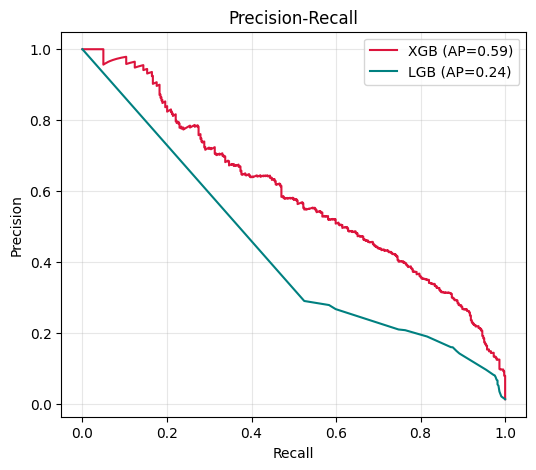

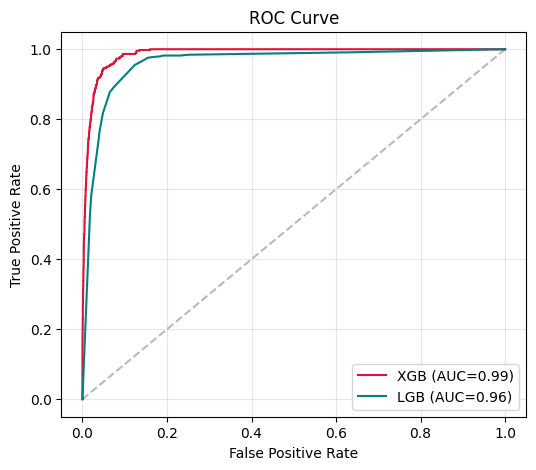

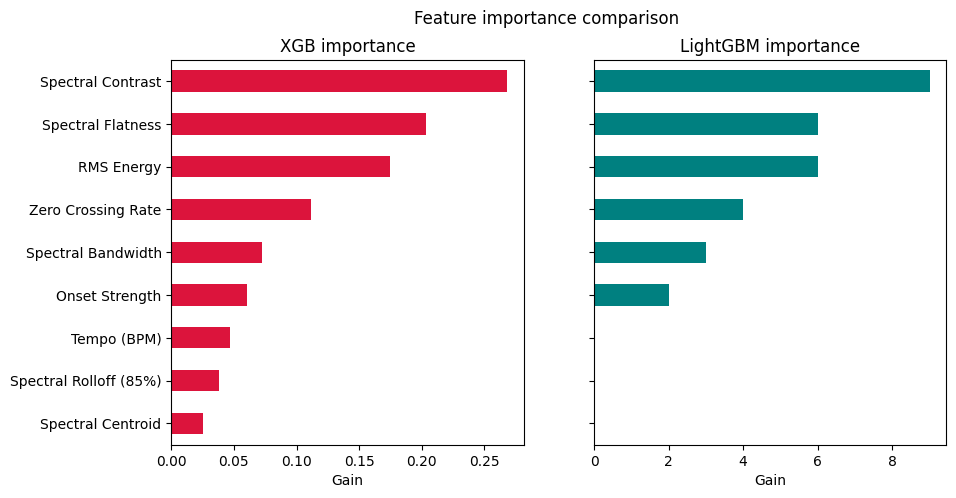

=== Summary (Audio-Moth 1 / simulation) ===
XGBoost   – AP 0.593 | ROC-AUC 0.987
LightGBM  – AP 0.238 | ROC-AUC 0.961


In [ ]:
y = df_A["sim_flag"].values
X_tr, X_te, y_tr, y_te = train_test_split(
    X_A, y, test_size=0.25, random_state=42, stratify=y
)
pos_w = (y_tr == 0).sum() / (y_tr == 1).sum()

xgb_clf = xgb.XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective="binary:logistic", scale_pos_weight=pos_w,
    eval_metric="logloss", n_jobs=-1, random_state=42
)
xgb_clf.fit(X_tr, y_tr)
proba_xgb = xgb_clf.predict_proba(X_te)[:,1]
ap_xgb    = average_precision_score(y_te, proba_xgb)
roc_auc_x = auc(*roc_curve(y_te, proba_xgb)[:2])

train_ds = lgb.Dataset(X_tr, label=y_tr)
valid_ds = lgb.Dataset(X_te, label=y_te, reference=train_ds)
lgb_params = dict(
    objective="binary", learning_rate=0.05, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=pos_w,
    metric="binary_logloss", seed=42
)
lgb_model = lgb.train(
    lgb_params, train_ds, num_boost_round=800, valid_sets=[valid_ds],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
)
proba_lgb = lgb_model.predict(X_te, num_iteration=lgb_model.best_iteration)
ap_lgb    = average_precision_score(y_te, proba_lgb)
roc_auc_l = auc(*roc_curve(y_te, proba_lgb)[:2])

prec_x, rec_x, _ = precision_recall_curve(y_te, proba_xgb)
prec_l, rec_l, _ = precision_recall_curve(y_te, proba_lgb)

plt.figure(figsize=(6,5))
plt.plot(rec_x, prec_x, label=f'XGB (AP={ap_xgb:.2f})', color='crimson')
plt.plot(rec_l, prec_l, label=f'LGB (AP={ap_lgb:.2f})', color='teal')
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall");
plt.legend(); plt.grid(alpha=.3); plt.show()

fpr_x, tpr_x, _ = roc_curve(y_te, proba_xgb)
fpr_l, tpr_l, _ = roc_curve(y_te, proba_lgb)
plt.figure(figsize=(6,5))
plt.plot(fpr_x, tpr_x, label=f'XGB (AUC={roc_auc_x:.2f})', color='crimson')
plt.plot(fpr_l, tpr_l, label=f'LGB (AUC={roc_auc_l:.2f})', color='teal')
plt.plot([0,1],[0,1],'k--',alpha=.3)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate");
plt.title("ROC Curve"); plt.legend(); plt.grid(alpha=.3); plt.show()

fig, ax = plt.subplots(1,2, figsize=(10,5), sharey=True)
(pd.Series(xgb_clf.feature_importances_, index=all_feature_cols)
   .sort_values().plot.barh(ax=ax[0], color='crimson'))
ax[0].set_title("XGB importance"); ax[0].set_xlabel("Gain")
(pd.Series(lgb_model.feature_importance(), index=all_feature_cols)
   .sort_values().plot.barh(ax=ax[1], color='teal'))
ax[1].set_title("LightGBM importance"); ax[1].set_xlabel("Gain")
plt.suptitle("Feature importance comparison"); plt.show()

print("=== Summary (Audio-Moth 1 / simulation) ===")
print(f"XGBoost   – AP {ap_xgb:.3f} | ROC-AUC {roc_auc_x:.3f}")
print(f"LightGBM  – AP {ap_lgb:.3f} | ROC-AUC {roc_auc_l:.3f}")


XGBoost clearly outperforms LightGBM on the simulation-detection task. Average-Precision 0.59 vs 0.24 and ROC-AUC 0.99 vs 0.96 show much better ranking quality. The PR-curve of XGB dominates across the whole recall range; at ≥ 0.9 recall it still keeps ≈ 0.20-0.25 precision, while LightGBM drops below 0.15. Feature gains are more evenly spread in XGB, whereas LightGBM relies on only ~6 features and prunes early.

Conclusion:

XGBoost already provides high recall (> 0.94) with the best precision so far (≈ 0.21). It is therefore the current baseline model for simulation detection on Audio-Moth data.

Next steps：

Ensemble for precision boost. Train 2-3 XGB models with different seeds / hyper-params (depth 3-5, η 0.03-0.07) and average probabilities.

Add contextual features （weather/hour of day）to capture environmental patterns that differ between real and playback clips. Keep recall ≥ 0.94 as a hard constraint; search threshold that maximises precision-at-recall metric.

Continue working on sliding window & energy threshold approaches.